# Esercizio 2: Confronto tra Insertion Sort e Quick Sort

**Nome:** Andrea  
**Cognome:** Petrucci  
**Matricola:** 7050922

Questo notebook analizza due algoritmi di ordinamento fondamentali: _**Insertion Sort**_ e **_Quick Sort_**. Esamineremo il loro funzionamento, complessità temporale e prestazioni pratiche attraverso esempi e confronti diretti. L'obiettivo è comprendere le differenze tra i due approcci e identificare i contesti in cui ciascun algoritmo è più efficiente.

### Prerequisiti del Sistema e Moduli

Per poter eseguire correttamente il notebook e i relativi benchmark, vengono utilizzati i seguenti moduli standard e di terze parti:
* **Moduli di sistema e utilità:** `sys` (gestione runtime), `random` (generazione dati), `time` (cronometraggio tempi).
* **Profiling e Type Hinting:** `tracemalloc` (monitoraggio RAM), `typing` (documentazione dei tipi di dato).
* **Grafica:** `matplotlib.pyplot` (generazione dei grafici).

Inoltre, viene modificato il limite di ricorsione nativo di Python a $10000$, per evitare eccezioni di `RecursionError` durante i benchmark sulle dimensioni massime dell'input, in particolare sul _Quick Sort_ quando gestisce distribuzioni di dati critiche (come gli array ricchi di elementi duplicati).

In [1]:
import random
import sys
import time
import tracemalloc
import matplotlib.pyplot as plt
from typing import Callable

# Incremento del limite di ricorsione per evitare crash del kernel su input critici
sys.setrecursionlimit(10000)

# Flag globale per abilitare/disabilitare il benchmark sulla memoria RAM
ENABLE_MEMORY_BENCHMARK = True

# Le dimensioni degli array da testare
SIZES = [5, 25, 50,100, 500, 1000, 2000, 5000]

## Funzioni di generazione di array
Di seguito vengono definite delle funzioni di per la generazione di array. Coprono i casi medi, migliori e peggiori, in modo tale da poter testare la robustezza e la velocità di _Insertion Sort_ e _Quick Sort_.

In [2]:
def generate_random_array(size: int) -> list[int]:
    """Genera un array di numeri casuali con dimensione in input."""
    return [random.randint(0, 100) for _ in range(size)]

def generate_sorted_array(size: int) -> list[int]:
    """Genera un array già ordinato con dimensione in input."""
    return list(range(size))

def generate_reverse_sorted_array(size: int) -> list[int]:
    """Genera un array ordinato in modo decrescente con dimensione in input."""
    return list(range(size, 0, -1))

def generate_almost_sorted_array(size: int, swap_count: int = None) -> list[int]:
    """Genera un array quasi ordinato con dimensione in input."""
    arr = list(range(size))
    if swap_count is None:
        swap_count = max(1, size // 20)  # Scambia fino al 5% degli elementi
    for _ in range(swap_count):
        i = random.randint(0, size - 1)
        j = random.randint(0, size - 1)
        arr[i], arr[j] = arr[j], arr[i]
    return arr

def generate_many_duplicates_array(size: int, value_range: int=10) -> list[int]:
    """Genera un array con molti elementi duplicati con dimensione in input."""
    return [random.randint(0, value_range) for _ in range(size)]

# Test delle funzioni di generazione array
N = 15
print(f"Test delle funzioni di generazione array (dimensione {N}):")
print(f"{'Casuale:':<25} {generate_random_array(N)}")
print(f"{'Ordinato crescente:':<25} {generate_sorted_array(N)}")
print(f"{'Ordinato decrescente:':<25} {generate_reverse_sorted_array(N)}")
print(f"{'Quasi ordinato:':<25} {generate_almost_sorted_array(N)}")
print(f"{'Molti duplicati:':<25} {generate_many_duplicates_array(N)}")


Test delle funzioni di generazione array (dimensione 15):
Casuale:                  [54, 31, 27, 95, 77, 78, 92, 92, 99, 1, 31, 74, 52, 99, 58]
Ordinato crescente:       [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]
Ordinato decrescente:     [15, 14, 13, 12, 11, 10, 9, 8, 7, 6, 5, 4, 3, 2, 1]
Quasi ordinato:           [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 11, 10, 12, 13, 14]
Molti duplicati:          [8, 7, 2, 2, 9, 8, 8, 3, 1, 6, 1, 3, 4, 3, 1]


## Insertion Sort
Costruisce l'array ordinato un elemento alla volta, inserendo ogni nuovo elemento nella posizione corretta tra quelli già ordinati. È efficiente per array piccoli o quasi ordinati, con complessità temporale $\Theta(n^2)$ nel caso peggiore e $\Theta(n)$ nel caso migliore.

In [3]:
def insertion_sort(arr: list[int]) -> None:
    """Ordina un array utilizzando l'algoritmo Insertion Sort."""
    for j in range(1, len(arr)):
        key = arr[j]
        i = j - 1
        while i >= 0 and key < arr[i]:
            arr[i + 1] = arr[i]
            i -= 1
        arr[i + 1] = key

## Quick Sort
È un algoritmo **Divide et Impera** che seleziona un elemento come pivot, partiziona l'array mettendo gli elementi minori a sinistra e i maggiori a destra, e ordina ricorsivamente i sottoarray. La versione classica possiede una complessità temporale media di $\Theta(n \lg n)$, ma precipita a $\Theta(n^2)$ nel caso peggiore (array già ordinati o inversamente ordinati). Per ovviare a questo limite intrinseco, in questa sede è stata implementata la versione randomizzata dell'algoritmo. L'estrazione casuale del pivot svincola le prestazioni dalla disposizione iniziale dei dati, mantenendo l'esecuzione estremamente efficiente nella pratica.

In [4]:
def partition(A: list[int], p: int,r: int) -> int:
    i=p-1
    for j in range (p,r):
        if A[j] <= A[r]:
            i = i+1
            A[i], A[j] = A[j], A[i]
    A[i+1], A[r] = A[r], A[i+1]
    return i+1

def randomized_partition(A: list[int], p: int,r: int) -> int:
    """Sceglie un pivot casuale e lo scambia con A[r] prima della partizione."""
    i = random.randint(p, r)
    A[i], A[r] = A[r], A[i]
    return partition(A,p,r)

def quick_sort(A: list[int], p: int,r: int) -> None:
    if p<r:
        q = randomized_partition(A,p,r)
        quick_sort(A,p,q-1)
        quick_sort(A,q+1,r)

## Benchmark e Confronto
Misuriamo il tempo di esecuzione di _Insertion Sort_ e _Quick Sort_ su array di dimensioni e ordinamenti diversi e confrontiamo le prestazioni tramite tabelle e grafici. 

Per evitare la ridondanza del codice (principio DRY) e garantire la coerenza metodologica dell'esperimento, la logica di calcolo dei tempi e di generazione dei grafici è stata astratta all'interno di un'unica funzione.

In [5]:
def run_benchmark(function_name: Callable[[int], list[int]], title: str, sizes: list[int], memory: bool = False) -> None:
    """
    Motore generico per eseguire il benchmark.
    - function_name: il nome della funzione che genera i dati
    - title: il testo da mostrare sopra il grafico
    - sizes: la lista di dimensioni degli array da testare
    - memory: se True, traccia anche la memoria allocata (più lento)
    """
    
    insertion_times = []
    quick_times = []
    insertion_memory = []
    quick_memory = []

    if memory:
        print(f"--- BENCHMARK TEMPO + MEMORIA: {title} ---")
        print("Dim\tTempo IS\tMem IS\tTempo QS\tMem QS")
        print("-" * 80)
    else:
        print(f"--- BENCHMARK TEMPO: {title} ---")
        print("Dim\tInsertion Sort\tQuick Sort")
        print("-" * 50)

    for size in sizes:
        # 1. Generiamo l'array
        arr = function_name(size)
        
        # 2. Test Insertion Sort
        arr_copy1 = arr.copy()
        start = time.perf_counter()
        if memory:
            tracemalloc.start()
        insertion_sort(arr_copy1)
        tempo_ins = time.perf_counter() - start
        insertion_times.append(tempo_ins)
        if memory:
            _, peak_ins = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            tracemalloc.clear_traces()
            insertion_memory.append(peak_ins / 1024)  # Converti in KB
        
        # 3. Test Quick Sort
        arr_copy2 = arr.copy()
        start = time.perf_counter()
        if memory:
            tracemalloc.start()
        quick_sort(arr_copy2, 0, len(arr_copy2) - 1)
        tempo_qs = time.perf_counter() - start
        quick_times.append(tempo_qs)
        if memory:
            _, peak_qs = tracemalloc.get_traced_memory()
            tracemalloc.stop()
            tracemalloc.clear_traces()
            quick_memory.append(peak_qs / 1024)  # Converti in KB
        
        # Stampa risultati
        if memory:
            print(f"{size}\t{tempo_ins:.6f}\t{peak_ins/1024:.1f}KB\t{tempo_qs:.6f}\t{peak_qs/1024:.1f}KB")
        else:
            print(f"{size}\t\t{tempo_ins:.6f}\t{tempo_qs:.6f}")
    
    # 4. Generazione dei grafici
    if memory:
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
        # Grafico tempo
        ax1.plot(sizes, insertion_times, marker='o', label='Insertion Sort', color='red')
        ax1.plot(sizes, quick_times, marker='s', label='Quick Sort', color='blue')
        ax1.set_xlabel("Dimensione dell'array (n)")
        ax1.set_ylabel("Tempo di esecuzione (secondi)")
        ax1.set_title(f"Tempo: {title}")
        ax1.legend()
        ax1.grid(True)
        # Grafico memoria
        ax2.plot(sizes, insertion_memory, marker='o', label='Insertion Sort', color='red')
        ax2.plot(sizes, quick_memory, marker='s', label='Quick Sort', color='blue')
        ax2.set_xlabel("Dimensione dell'array (n)")
        ax2.set_ylabel("Memoria allocata (KB)")
        ax2.set_title(f"Memoria: {title}")
        ax2.legend()
        ax2.grid(True)
        plt.tight_layout()
    else:
        # Solo grafico tempo
        plt.figure(figsize=(10, 6))
        plt.plot(sizes, insertion_times, marker='o', label='Insertion Sort', color='red')
        plt.plot(sizes, quick_times, marker='s', label='Quick Sort', color='blue')
        plt.xlabel("Dimensione dell'array (n)")
        plt.ylabel("Tempo di esecuzione (secondi)")
        plt.title(f"Confronto: {title}")
        plt.legend()
        plt.grid(True)
    plt.show()

### Benchmark 1: Array con numeri casuali

Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array con numeri casuali, per confrontare le loro prestazioni.

--- BENCHMARK TEMPO + MEMORIA: Array Casuale (Valori sparsi) ---
Dim	Tempo IS	Mem IS	Tempo QS	Mem QS
--------------------------------------------------------------------------------
5	0.000514	0.1KB	0.000033	0.1KB
25	0.000028	0.1KB	0.000090	0.1KB
50	0.000046	0.1KB	0.000181	0.1KB
100	0.000150	0.1KB	0.000234	0.1KB
500	0.043198	1.3KB	0.006819	1.8KB
1000	0.380837	4.2KB	0.020366	1.6KB
2000	1.364897	3.4KB	0.064668	2.5KB
5000	10.029658	3.5KB	0.342430	4.8KB


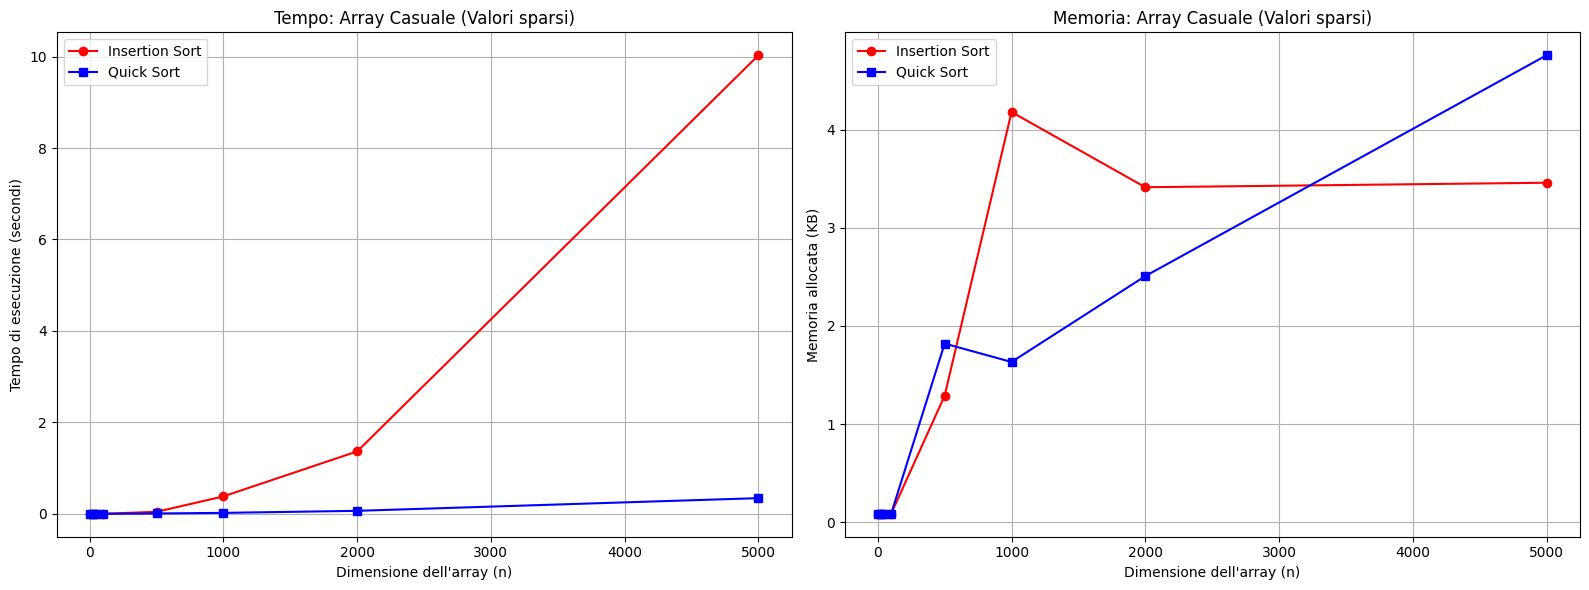

In [6]:
run_benchmark(generate_random_array, "Array Casuale (Valori sparsi)", SIZES, ENABLE_MEMORY_BENCHMARK)

### Benchmark 2: Array Ordinato (crescente)
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array ordinato in modo crescente, per confrontare le loro prestazioni nel caso migliore per _Insertion Sort_ e quello che rappresenterebbe il caso peggiore per il _Quick Sort_ classico (con pivot fisso), evidenziando così l'efficacia della variante randomizzata qui adottata.


--- BENCHMARK TEMPO + MEMORIA: Array Ordinato (Valori crescenti) ---
Dim	Tempo IS	Mem IS	Tempo QS	Mem QS
--------------------------------------------------------------------------------
5	0.000011	0.1KB	0.000026	0.1KB
25	0.000004	0.1KB	0.000057	0.1KB
50	0.000006	0.1KB	0.000109	0.1KB
100	0.000009	0.1KB	0.000228	0.1KB
500	0.000579	0.1KB	0.005528	1.9KB
1000	0.001746	0.1KB	0.015694	1.5KB
2000	0.004265	0.1KB	0.039611	1.9KB
5000	0.010886	0.3KB	0.111227	2.6KB


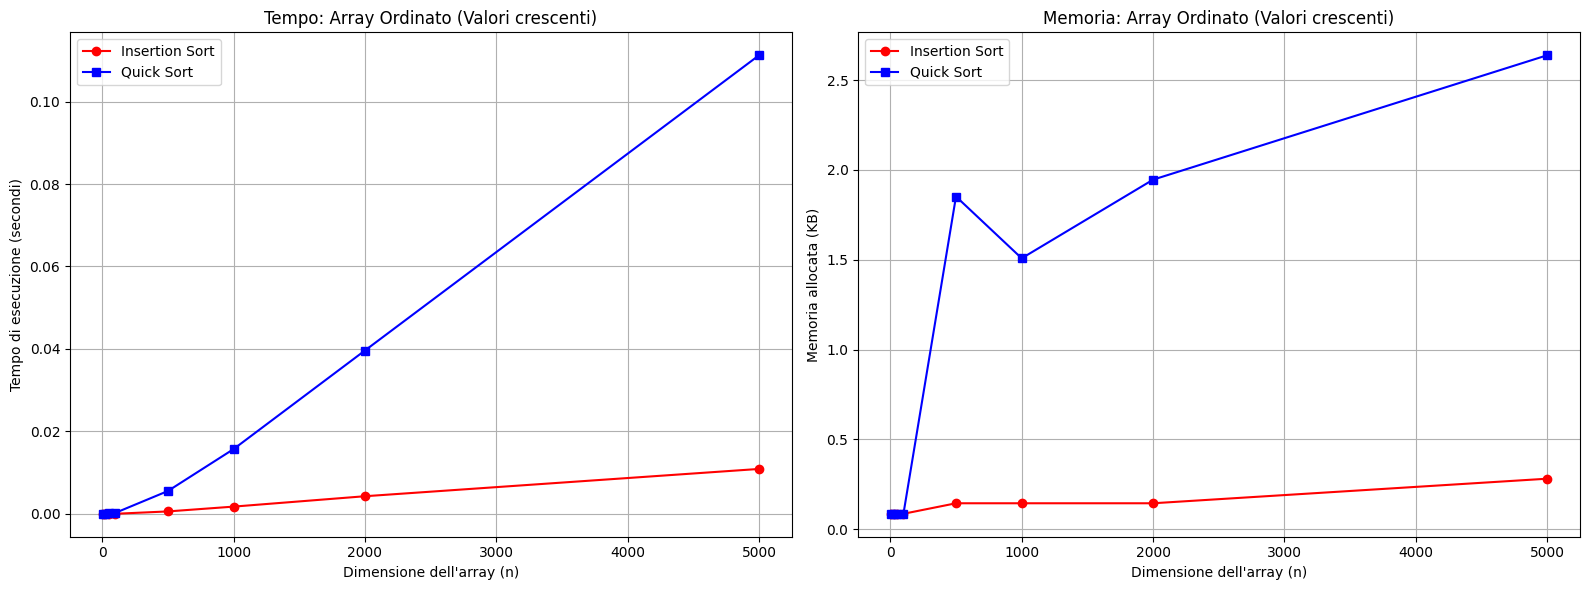

In [7]:
run_benchmark(generate_sorted_array, "Array Ordinato (Valori crescenti)", SIZES, ENABLE_MEMORY_BENCHMARK)


### Benchmark 3: Array Ordinato (decrescente)
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array ordinato in modo decrescente, per confrontare le loro prestazioni nel caso peggiore per _Insertion Sort_.

--- BENCHMARK TEMPO + MEMORIA: Array Ordinato (Valori decrescenti) ---
Dim	Tempo IS	Mem IS	Tempo QS	Mem QS
--------------------------------------------------------------------------------
5	0.000043	0.1KB	0.000069	0.1KB
25	0.000028	0.1KB	0.000077	0.1KB
50	0.000115	0.1KB	0.000221	0.1KB
100	0.000421	0.1KB	0.000569	0.1KB
500	0.078123	1.3KB	0.004780	1.2KB
1000	0.472120	4.2KB	0.014552	1.2KB
2000	2.461763	3.4KB	0.036983	1.5KB
5000	16.904965	3.3KB	0.092457	1.9KB


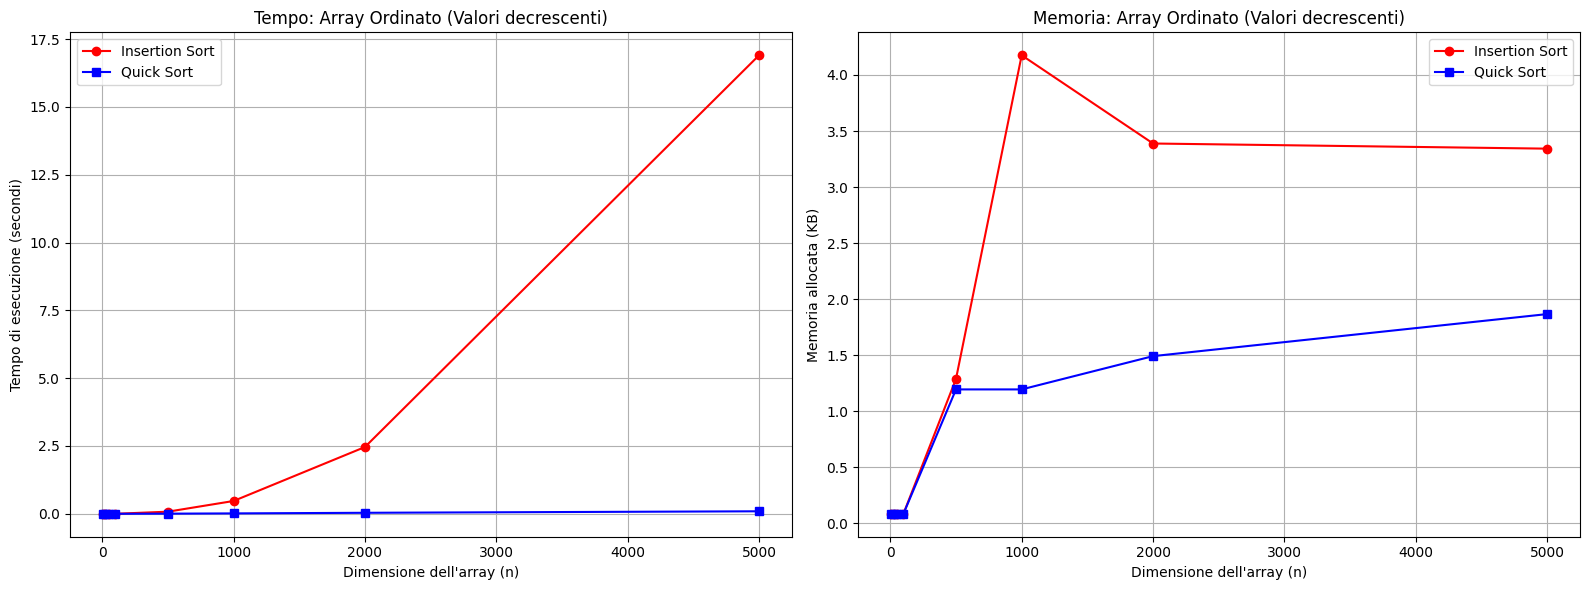

In [8]:
run_benchmark(generate_reverse_sorted_array, "Array Ordinato (Valori decrescenti)", SIZES, ENABLE_MEMORY_BENCHMARK)

### Benchmark 4: Array Quasi Ordinato
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array quasi ordinato, un contesto comune in molte applicazioni reali.

--- BENCHMARK TEMPO + MEMORIA: Array Quasi Ordinato ---
Dim	Tempo IS	Mem IS	Tempo QS	Mem QS
--------------------------------------------------------------------------------
5	0.000011	0.1KB	0.000015	0.1KB
25	0.000005	0.1KB	0.000055	0.1KB
50	0.000012	0.1KB	0.000101	0.1KB
100	0.000026	0.1KB	0.000210	0.1KB
500	0.005501	1.0KB	0.004176	1.0KB
1000	0.043070	1.5KB	0.014281	1.3KB
2000	0.137229	1.6KB	0.034277	1.6KB
5000	1.097679	3.7KB	0.103187	2.3KB


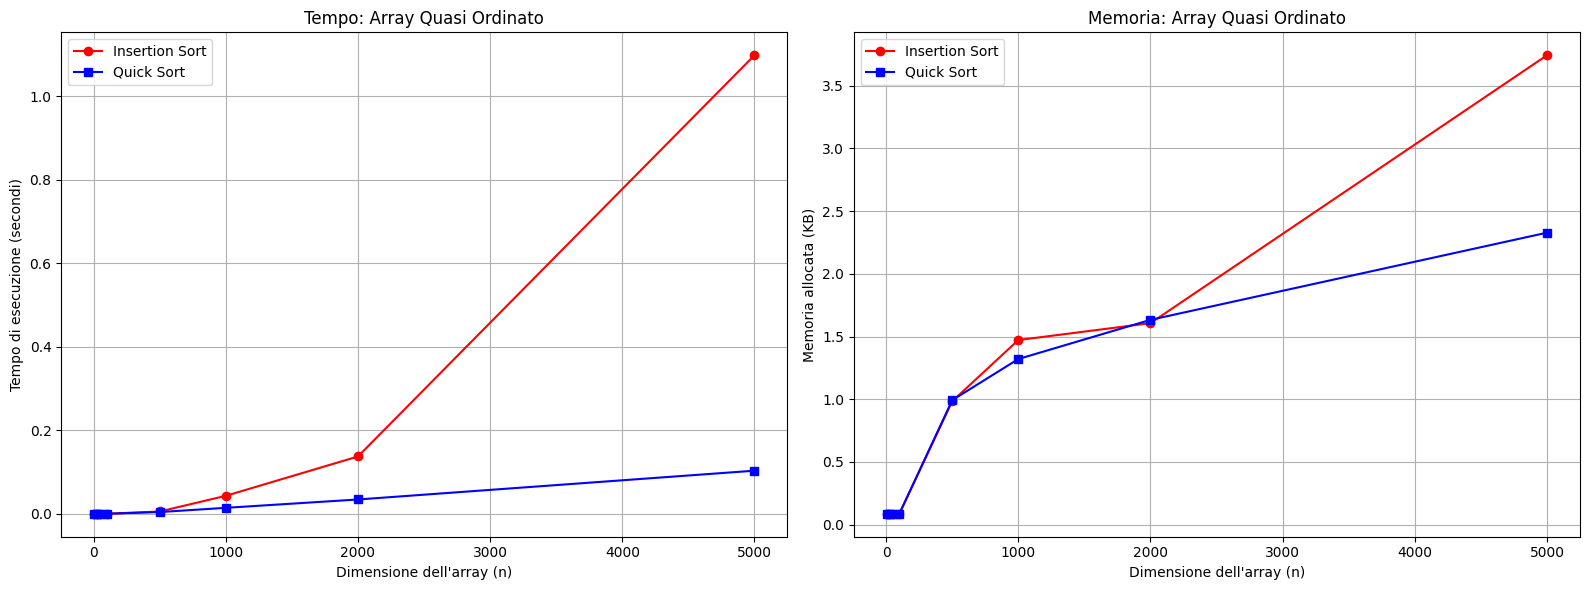

In [9]:
run_benchmark(generate_almost_sorted_array, "Array Quasi Ordinato", SIZES, ENABLE_MEMORY_BENCHMARK)

### Benchmark 5: Array con Molti Duplicati
Testiamo sia _Insertion Sort_ che _Quick Sort_ su un array con molti elementi duplicati, un contesto che si verifica spesso in dati reali.


--- BENCHMARK TEMPO + MEMORIA: Array Con molti duplicati ---
Dim	Tempo IS	Mem IS	Tempo QS	Mem QS
--------------------------------------------------------------------------------
5	0.000011	0.1KB	0.000015	0.1KB
25	0.000012	0.1KB	0.000064	0.1KB
50	0.000044	0.1KB	0.000134	0.1KB
100	0.000148	0.1KB	0.000323	0.1KB
500	0.036640	2.0KB	0.013176	3.6KB
1000	0.262341	4.2KB	0.072221	7.2KB
2000	1.219362	3.3KB	0.345256	13.4KB
5000	7.893533	3.3KB	3.589660	30.1KB


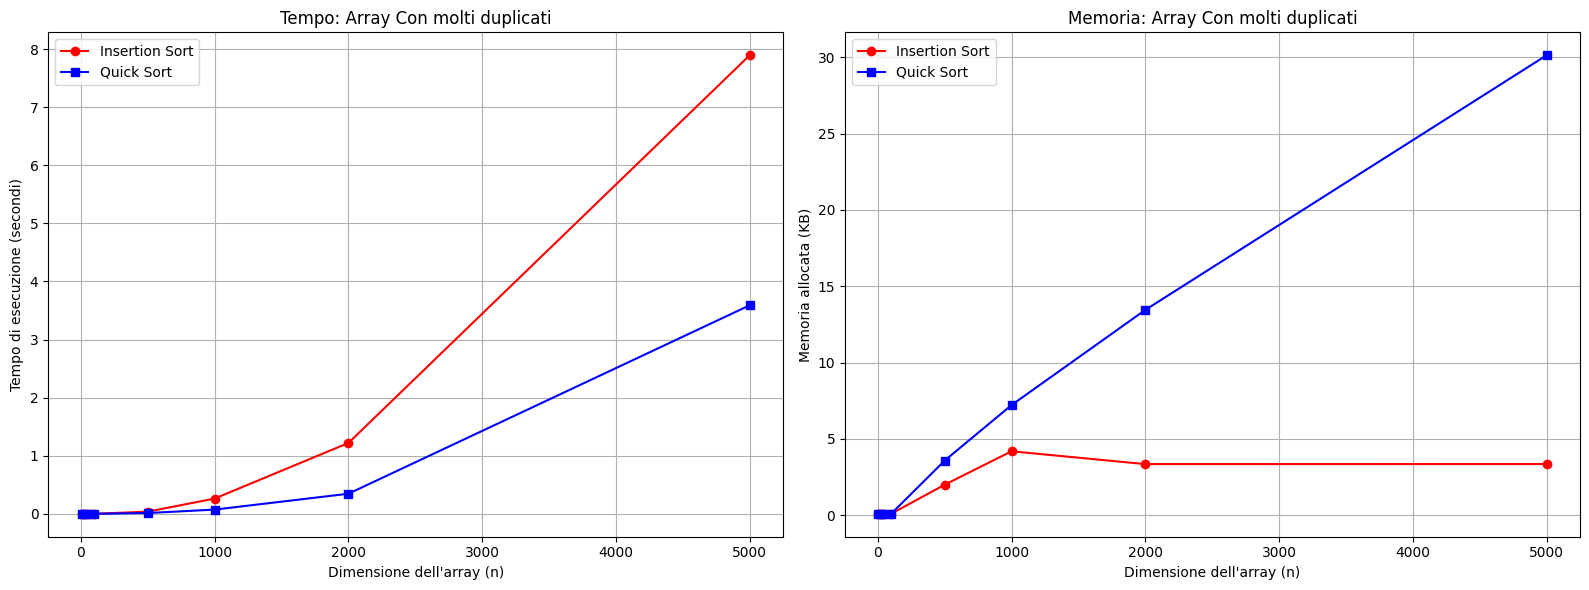

In [10]:
run_benchmark(generate_many_duplicates_array, "Array Con molti duplicati", SIZES, ENABLE_MEMORY_BENCHMARK)

## Conclusioni e Analisi dei Risultati

L'analisi dei benchmark conferma empiricamente il comportamento asintotico teorico dell'_Insertion Sort_ e del _Quick Sort_:

*   **Caso Medio (Array Casuali):** Come atteso, il _Quick Sort_ surclassa nettamente l'_Insertion Sort_ al crescere di $n$. La curva del tempo dell'_Insertion Sort_ cresce in modo parabolico $\Theta(n^2)$, mentre il _Quick Sort_ mantiene una crescita quasi piatta, coerente con il suo limite logaritmico $\Theta(n \lg n)$.
*   **Caso Migliore vs Peggiore (Array Ordinati e Inversi):** L'esperimento sull'array ordinato in modo crescente evidenzia il vero punto di forza dell'_Insertion Sort_: non entrando mai nel ciclo `while` interno, il tempo di esecuzione collassa a una retta lineare $\Theta(n)$, risultando estremamente veloce. Al contrario, l'array ordinato in modo decrescente costringe l'_Insertion Sort_ al numero massimo di scambi, innescando il caso pessimo assoluto $\Theta(n^2)$.
*   **L'importanza del Pivot Randomico:** Nel benchmark con array già ordinati, il _Quick Sort_ classico avrebbe generato partizioni totalmente sbilanciate, degradando a $\Theta(n^2)$. Grazie all'implementazione del pivot randomizzato utilizzata in questo notebook, l'algoritmo ha mantenuto tempi eccellenti $\Theta(n \lg n)$ indipendentemente dalla pre-ordinazione dei dati.
*   **Efficienza sulle Piccole Dimensioni:** Osservando i log testuali per input microscopici ($N=5, N=25$), l'_Insertion Sort_ risulta spesso competitivo o marginalmente superiore al _Quick Sort_. Questo dimostra che, per porzioni di dati estremamente ridotte, i fattori costanti bassi e l'assenza di chiamate ricorsive (overhead) rendono l'_Insertion Sort_ un algoritmo altamente efficiente.

Il _Quick Sort_ randomizzato si conferma l'algoritmo *general-purpose* dominante per grandi moli di dati. Tuttavia, l'_Insertion Sort_ resta una scelta ingegneristica validissima (e spesso preferibile) per array di piccolissime dimensioni o per dati che si sanno essere già quasi completamente ordinati.